# 近赤外スペクトル分析チャレンジ — EDA

このNotebookでは以下の順番でデータを探索します。

1. ライブラリの読み込み・データ準備
2. 基本情報の確認
3. 目的変数（含水率）の分布
4. 樹種ごとの含水率比較
5. スペクトルの可視化
6. 含水率との相関分析
7. Train / Test の比較
8. EDAまとめ・次のアクション

## 1. ライブラリの読み込み・データ準備

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Noto Sans CJK JP を指定（環境に既存のフォント）
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['figure.dpi'] = 120

print('ライブラリの読み込み完了')

ライブラリの読み込み完了


In [2]:
# --- データの読み込み ---
# CSVはShift-JISエンコーディングで保存されています
train = pd.read_csv('../data/train.csv', encoding='shift-jis')
test  = pd.read_csv('../data/test.csv',  encoding='shift-jis')
sample_sub = pd.read_csv('../data/sample_submit.csv', encoding='shift-jis')

# --- 列名を英語に統一（後の処理をしやすくするため）---
train.columns = (
    ['sample_number', 'species_number', 'species_name', 'moisture_content']
    + list(train.columns[4:])
)
test.columns = (
    ['sample_number', 'species_number', 'species_name']
    + list(test.columns[3:])
)

# スペクトル列名（波数）のリストを作っておく
spec_cols   = list(train.columns[4:])
wavelengths = np.array([float(c) for c in spec_cols])

print(f'train: {train.shape}')
print(f'test:  {test.shape}')
print(f'スペクトル列数: {len(spec_cols)}')
print(f'波数の範囲: {wavelengths.max():.1f} 〜 {wavelengths.min():.1f} cm⁻¹')

train: (1322, 1559)
test:  (550, 1558)
スペクトル列数: 1555
波数の範囲: 9993.8 〜 3999.8 cm⁻¹


## 2. 基本情報の確認

In [3]:
# 欠損値の確認（0であれば問題なし）
print('=== 欠損値 ===')
print(f'train: {train.isnull().sum().sum()}')
print(f'test:  {test.isnull().sum().sum()}')

=== 欠損値 ===
train: 0
test:  0


In [4]:
# 先頭数行を確認（非スペクトル列だけ表示）
train[['sample_number', 'species_number', 'species_name', 'moisture_content']].head(8)

,sample_number,species_number,species_name,moisture_content
0,1,1,イチョウ,216.129032
1,2,1,イチョウ,210.752688
2,3,1,イチョウ,205.913979
3,4,1,イチョウ,201.075269
4,5,1,イチョウ,196.236559
5,6,1,イチョウ,191.397850
6,7,1,イチョウ,186.559140
7,8,1,イチョウ,182.258064


In [5]:
# 樹種名の対応表（species_number → species_name）
species_map = (
    train[['species_number', 'species_name']]
    .drop_duplicates()
    .sort_values('species_number')
    .reset_index(drop=True)
)
print(species_map.to_string(index=False))

 species_number species_name
              1         イチョウ
              3         ウエンジ
              4      ウォールナット
              5           クリ
              8        スプルース
             11         チェリー
             12           トチ
             13           ナラ
             14          ヒノキ
             15         ベイスギ
             16          米ヒバ
             17         ベイマツ
             19      ホワイトオーク


## 3. 目的変数（含水率）の分布

**なぜ見るか**: 分布の形によって、対数変換の必要性やモデルの選択方針が変わるため。

In [6]:
mc = train['moisture_content']
print('=== 含水率の統計量 ===')
print(mc.describe().round(2))
print(f'歪度 (skewness): {mc.skew():.3f}  ← 1.0以上で右に強く偏っている')
print(f'尖度 (kurtosis): {mc.kurt():.3f}')

=== 含水率の統計量 ===
count    1322.00
mean       49.94
std        49.54
min         0.84
25%        16.11
50%        29.05
75%        70.26
max       298.58
Name: moisture_content, dtype: float64
歪度 (skewness): 1.649  ← 1.0以上で右に強く偏っている
尖度 (kurtosis): 2.762


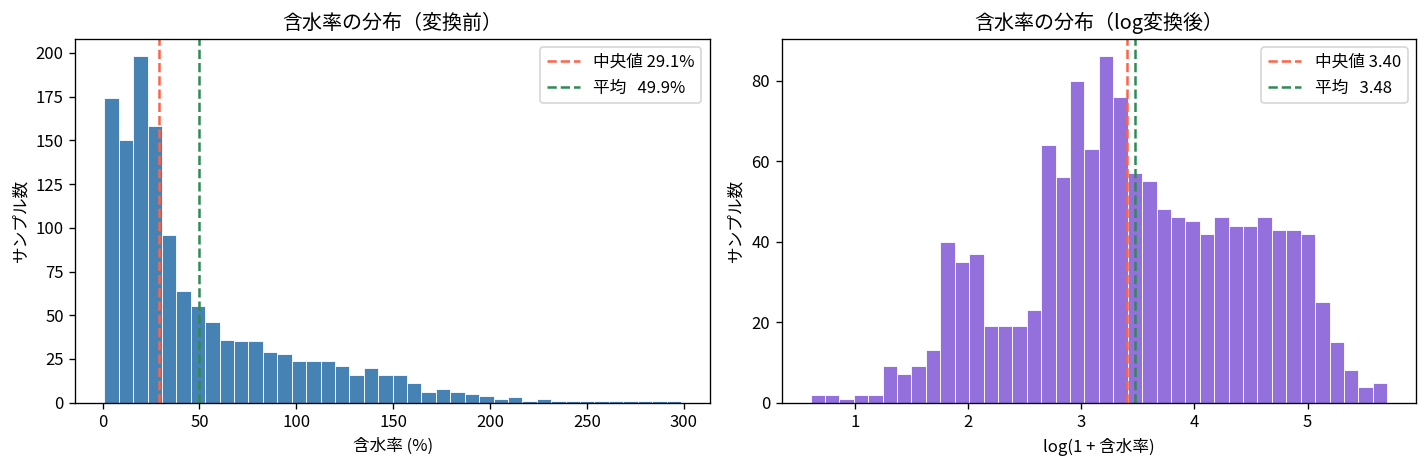

変換後の歪度: -0.106 ← 0に近いほど正規分布に近い


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 変換前
axes[0].hist(mc, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(mc.median(), color='tomato',   linestyle='--', label=f'中央値 {mc.median():.1f}%')
axes[0].axvline(mc.mean(),   color='seagreen', linestyle='--', label=f'平均   {mc.mean():.1f}%')
axes[0].set_title('含水率の分布（変換前）')
axes[0].set_xlabel('含水率 (%)')
axes[0].set_ylabel('サンプル数')
axes[0].legend()

# 対数変換後（log1p = log(1+x)）
log_mc = np.log1p(mc)
axes[1].hist(log_mc, bins=40, color='mediumpurple', edgecolor='white', linewidth=0.5)
axes[1].axvline(log_mc.median(), color='tomato',   linestyle='--', label=f'中央値 {log_mc.median():.2f}')
axes[1].axvline(log_mc.mean(),   color='seagreen', linestyle='--', label=f'平均   {log_mc.mean():.2f}')
axes[1].set_title('含水率の分布（log変換後）')
axes[1].set_xlabel('log(1 + 含水率)')
axes[1].set_ylabel('サンプル数')
axes[1].legend()

plt.tight_layout()
plt.show()
print('変換後の歪度:', round(log_mc.skew(), 3), '← 0に近いほど正規分布に近い')

## 4. 樹種ごとの含水率比較

**なぜ見るか**: 樹種によって含水率の傾向が大きく違う場合、樹種情報をモデルに活かす必要があるため。

In [8]:
# 樹種ごとの統計量
summary = train.groupby('species_number').agg(
    サンプル数=('moisture_content', 'count'),
    最小値=('moisture_content', 'min'),
    中央値=('moisture_content', 'median'),
    平均値=('moisture_content', 'mean'),
    最大値=('moisture_content', 'max'),
).round(1)
print(summary)

                サンプル数   最小値   中央値   平均値    最大値
species_number                                
1                  94  17.2  57.3  78.0  216.1
3                  87   4.2  10.8  15.5   58.7
4                 110  24.2  40.6  57.2  156.2
5                  91  23.2  58.0  73.2  180.4
8                  97   0.8  15.5  37.1  160.1
11                 88   4.1  28.4  53.4  158.9
12                183  13.3  20.1  31.6  153.8
13                107  16.9  32.6  41.8  114.1
14                141   1.0   7.3  39.6  198.5
15                112  12.8  57.4  88.3  298.6
16                 68  18.6  56.8  70.1  180.5
17                 93   2.6  28.5  41.8  138.9
19                 51  12.2  26.5  33.4   84.9


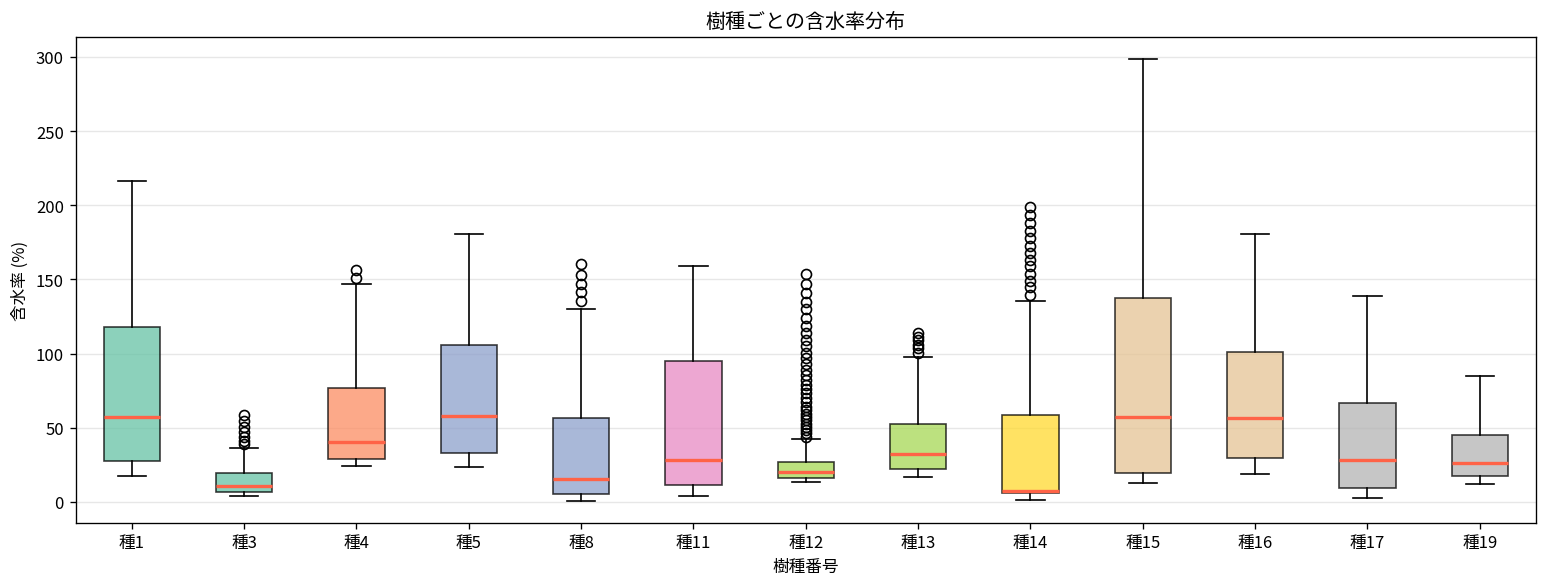

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))

species_list = sorted(train['species_number'].unique())
data_by_sp   = [train[train['species_number'] == s]['moisture_content'].values
                for s in species_list]

bp = ax.boxplot(data_by_sp, tick_labels=[f'種{s}' for s in species_list],
                patch_artist=True,
                medianprops=dict(color='tomato', linewidth=2))

colors = plt.cm.Set2(np.linspace(0, 1, len(species_list)))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)

ax.set_title('樹種ごとの含水率分布')
ax.set_xlabel('樹種番号')
ax.set_ylabel('含水率 (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. スペクトルの可視化

**なぜ見るか**: スペクトルの形やノイズの大きさを確認し、前処理の方針（平滑化・正規化など）を決めるため。

/tmp/ipykernel_1492267/2283907033.py:16: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/home/mhatanaka/signate/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.print_figure(bytes_io, **kw)


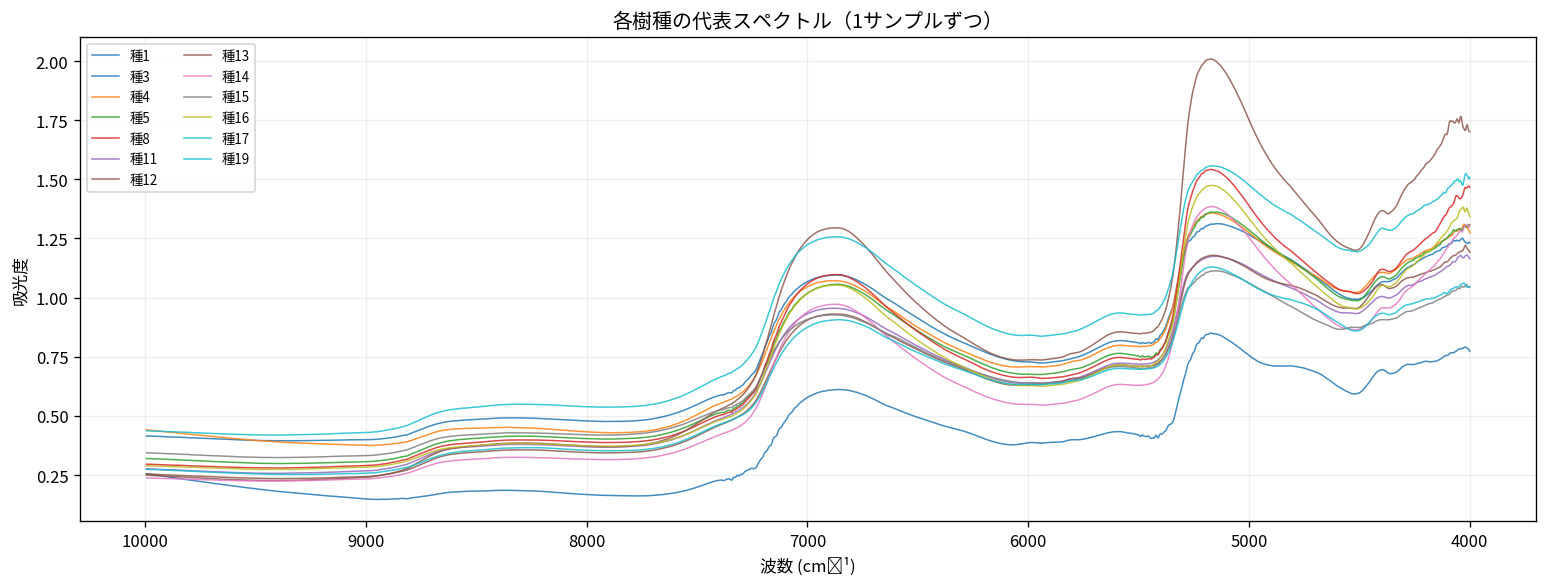

In [10]:
# 各樹種の代表スペクトルを1本ずつ表示
fig, ax = plt.subplots(figsize=(13, 5))

palette = plt.cm.tab10(np.linspace(0, 1, len(species_list)))
for s, c in zip(species_list, palette):
    sample = train[train['species_number'] == s].iloc[0]
    ax.plot(wavelengths, sample[spec_cols].values,
            color=c, linewidth=0.9, label=f'種{s}', alpha=0.85)

ax.invert_xaxis()  # 近赤外スペクトルは右→左に表示する慣習
ax.set_title('各樹種の代表スペクトル（1サンプルずつ）')
ax.set_xlabel('波数 (cm⁻¹)')
ax.set_ylabel('吸光度')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1492267/3086769909.py:33: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()


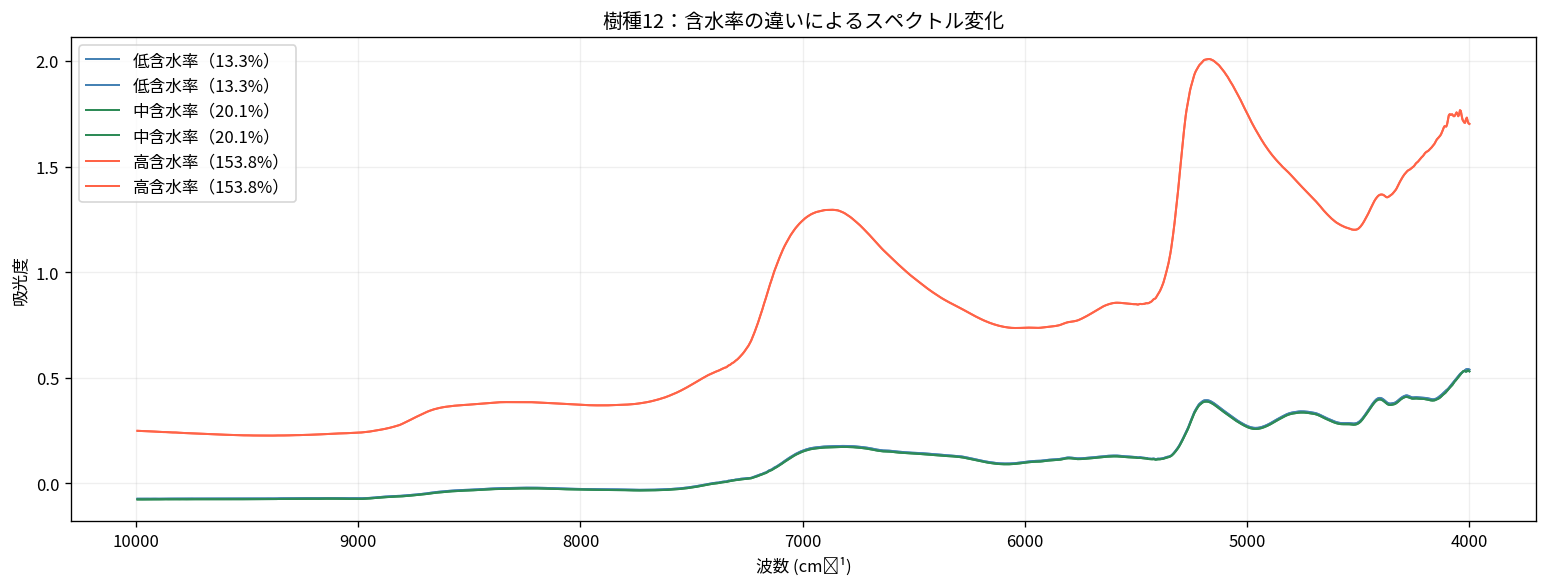

In [11]:
# 同じ樹種で含水率が異なるサンプルを重ねて比較
# → 含水率が高いほどスペクトルがどう変わるかを確認する
TARGET_SPECIES = 12  # ← サンプル数が多い種12で確認（他の番号に変えてもOK）

sp_data = train[train['species_number'] == TARGET_SPECIES].copy()
sp_data = sp_data.sort_values('moisture_content')

# 含水率が低・中・高の3サンプルを選ぶ
n = len(sp_data)
indices = [0, n // 2, n - 1]
selected = sp_data.iloc[indices]

fig, ax = plt.subplots(figsize=(13, 5))
colors_mc = ['steelblue', 'seagreen', 'tomato']
labels_mc = ['低含水率', '中含水率', '高含水率']

for row, color, label in zip(selected.itertuples(), colors_mc, labels_mc):
    mc_val = row.moisture_content
    # 直接スペクトルデータを取得するように修正
    spec = sp_data.loc[row.Index, spec_cols].values
    ax.plot(wavelengths, spec, color=color, linewidth=1.2,
            label=f'{label}（{mc_val:.1f}%）')
    spec = sp_data.loc[row.Index, spec_cols].values
    ax.plot(wavelengths, spec, color=color, linewidth=1.2,
            label=f'{label}（{mc_val:.1f}%）')

ax.invert_xaxis()
ax.set_title(f'樹種{TARGET_SPECIES}：含水率の違いによるスペクトル変化')
ax.set_xlabel('波数 (cm⁻¹)')
ax.set_ylabel('吸光度')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 6. 含水率との相関分析

**なぜ見るか**: どの波数帯が予測に効くかを把握し、特徴量選択や注目波数の手がかりにするため。

In [12]:
# 各波数と含水率のPearson相関係数を一括計算
corr = train[spec_cols].corrwith(train['moisture_content'])

print('=== 相関が高い波数 TOP 10 ===')
top10 = corr.abs().nlargest(10)
for col, _ in top10.items():
    print(f'  {float(col):>9.2f} cm⁻¹  r = {corr[col]:.4f}')

=== 相関が高い波数 TOP 10 ===
    7617.79 cm⁻¹  r = 0.7791
    7621.65 cm⁻¹  r = 0.7791
    7613.93 cm⁻¹  r = 0.7791
    7625.50 cm⁻¹  r = 0.7790
    7610.07 cm⁻¹  r = 0.7790
    7633.22 cm⁻¹  r = 0.7790
    7629.36 cm⁻¹  r = 0.7790
    7606.22 cm⁻¹  r = 0.7790
    7637.07 cm⁻¹  r = 0.7790
    7602.36 cm⁻¹  r = 0.7789


/tmp/ipykernel_1492267/2416377157.py:16: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()


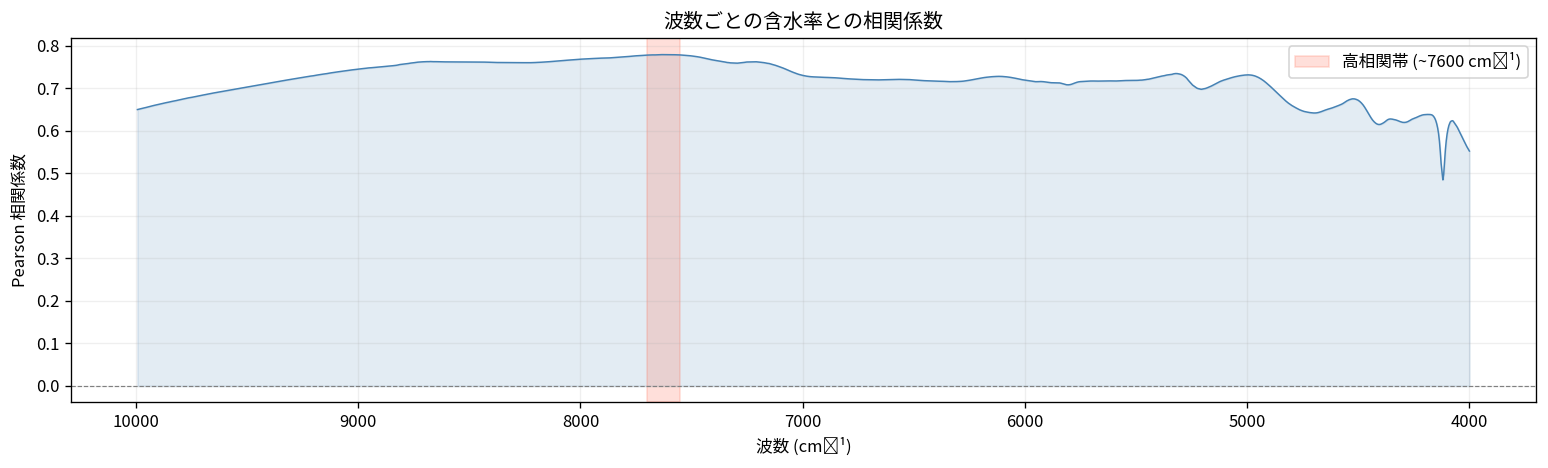

In [13]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(wavelengths, corr.values, color='steelblue', linewidth=0.9)
ax.fill_between(wavelengths, corr.values, alpha=0.15, color='steelblue')
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')

# 高相関帯を色で強調
ax.axvspan(7550, 7700, alpha=0.2, color='tomato', label='高相関帯 (~7600 cm⁻¹)')

ax.invert_xaxis()
ax.set_title('波数ごとの含水率との相関係数')
ax.set_xlabel('波数 (cm⁻¹)')
ax.set_ylabel('Pearson 相関係数')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Train / Test の比較

**なぜ見るか**: trainにない樹種がtestに出てきたり、スペクトルの分布が大きくずれている場合、モデルの汎化性能が下がるリスクがあるため。

In [14]:
train_species = set(train['species_number'].unique())
test_species  = set(test['species_number'].unique())

print('train の樹種:', sorted(train_species))
print('test  の樹種:', sorted(test_species))
print()
print('test にしかいない樹種:', sorted(test_species - train_species))
print('train にしかいない樹種:', sorted(train_species - test_species))
print()
print('⚠ trainとtestで樹種が完全に分かれています。')
print('  「学習に使っていない樹種を予測する」タスクです。')

train の樹種: [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19)]
test  の樹種: [np.int64(2), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(18)]

test にしかいない樹種: [np.int64(2), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(18)]
train にしかいない樹種: [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19)]

⚠ trainとtestで樹種が完全に分かれています。
  「学習に使っていない樹種を予測する」タスクです。


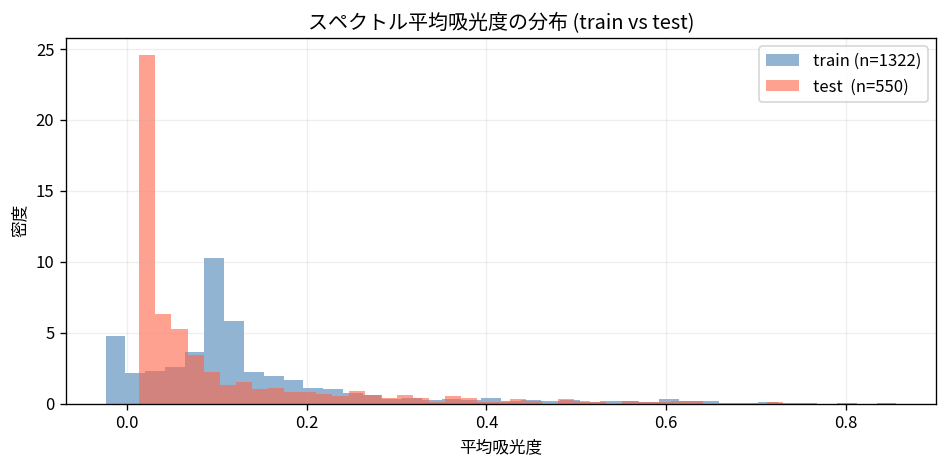

train 平均: 0.1330  test 平均: 0.0940


In [15]:
# スペクトルの全体的な分布をtrain/testで比較
# （全波数の平均吸光度をサンプルごとに計算して比較）
train_mean_spec = train[spec_cols].mean(axis=1)
test_mean_spec  = test[spec_cols].mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_mean_spec, bins=40, alpha=0.6, color='steelblue',
        label=f'train (n={len(train)})', density=True)
ax.hist(test_mean_spec,  bins=40, alpha=0.6, color='tomato',
        label=f'test  (n={len(test)})',  density=True)
ax.set_title('スペクトル平均吸光度の分布 (train vs test)')
ax.set_xlabel('平均吸光度')
ax.set_ylabel('密度')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print(f'train 平均: {train_mean_spec.mean():.4f}  test 平均: {test_mean_spec.mean():.4f}')

## 8. EDAまとめ・次のアクション

| 発見 | 対応方針 |
|------|----------|
| 含水率が右に強く偏っている（歪度 1.65） | 目的変数を **log変換** して学習する |
| 樹種によって含水率の範囲が大きく異なる | 樹種情報を特徴量として活用する |
| **trainとtestで樹種が完全に分離** | 樹種番号をそのまま使うのは危険。スペクトル自体の特徴を使う設計が必要 |
| 7600 cm⁻¹付近の相関が特に高い | 前処理後もこの帯域に注目する |
| スペクトルのベースラインが樹種間でずれている | **SNV（標準正規変量変換）** や **MSC** などの前処理を検討する |

### 次にやること

1. 前処理の設計（SNV・微分・次元削減など）
2. ベースラインモデルの構築（まず動くものを作る）
3. バリデーション戦略の設計（樹種分離を踏まえたCV設計）